# Эксперимтенты

In [8]:
from pathlib import Path
import rasterio as rs


raster_path = Path(r"D:\ml_datasets\Chukotka\DEM\dem_120m.tif")
ds = rs.open(raster_path)

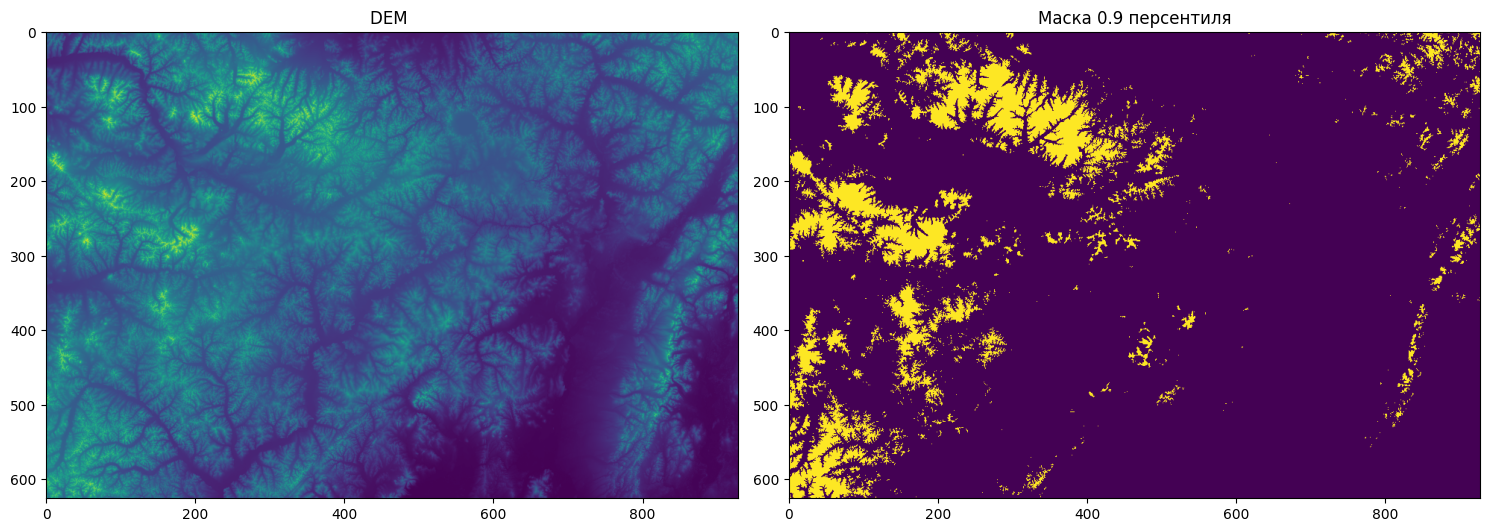

In [9]:
import torch
import matplotlib.pyplot as plt

p = 0.9
fig, ax = plt.subplots(1, 2, figsize = (15, 6))
tensor = torch.tensor(ds.read(1))
p95 = torch.quantile(tensor.flatten()[::100], p)  # используйте перцентиль
binmask = tensor > p95

ax[0].imshow(tensor[::10, ::10])
ax[0].set_title('DEM ')
ax[1].imshow(binmask[::10, ::10])
ax[1].set_title(f'Маска {p} персентиля')

plt.tight_layout()
plt.show()

# Box-counting method

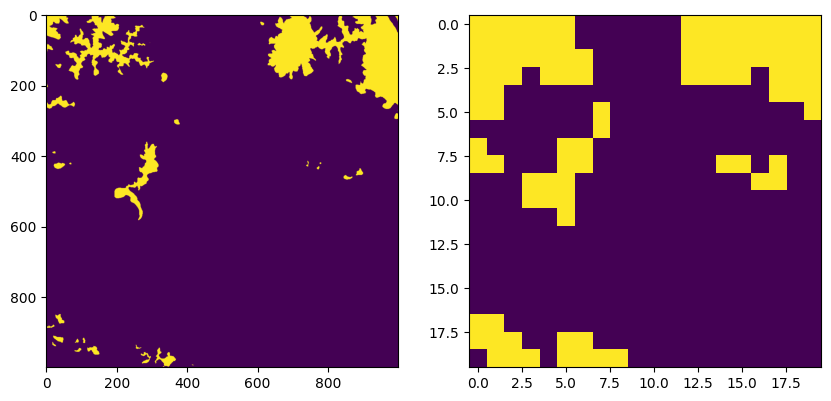

In [10]:
fig, ax = plt.subplots(1, 2, figsize= (10, 10))

cropped = binmask[1000:2000, 1000:2000]
ax[0].imshow(cropped)


# MaxPool2d - добавляем batch и channel размерности
cropped_tensor = cropped.float().unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
pooled = torch.nn.functional.max_pool2d(cropped_tensor, kernel_size=50)
pooled = pooled.squeeze()  # обратно в 2D [H/10, W/10]

ax[1].imshow(pooled)

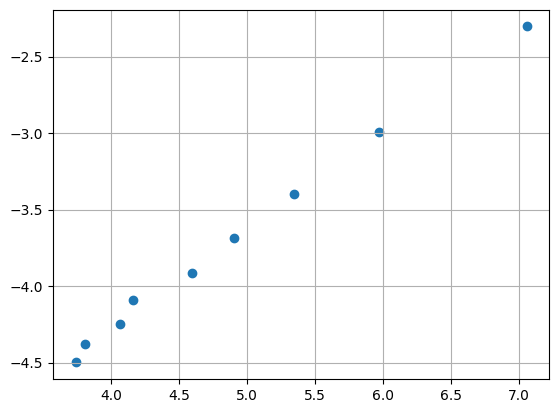

In [11]:
from utils.box_counting import count_boxes


box_count = []
box_size = []
for i in range(1, 10):
    size = i*10
    box_size.append(size)
    box_count.append(count_boxes(
        cropped,
        box_size=size
    ))

from sklearn.linear_model import LinearRegression
import numpy as np


reg = LinearRegression().fit(np.log(box_count).reshape(-1, 1), -np.log(box_size))

plt.scatter(np.log(box_count), -np.log(box_size))
plt.grid()

# Анализ линеаментов

In [12]:
from pathlib import Path
import torch

from utils.box_counting import get_fractal_dimention
import rasterio as rs

lineaments_dir = Path(r"D:\ml_datasets\Chukotka\DEM\scaled_lineaments")
lineaments = {}
for f in lineaments_dir.iterdir():
    title = f.stem.split("_")[-1]
    scale = int(title.replace('m', ""))
    lineaments[scale] = f

fractal_scales = {}
for scale in lineaments:
    dem_tensor = torch.tensor(rs.open(lineaments[scale]).read(1))
    fractal_scales[scale] = get_fractal_dimention(dem_tensor > dem_tensor.mean())


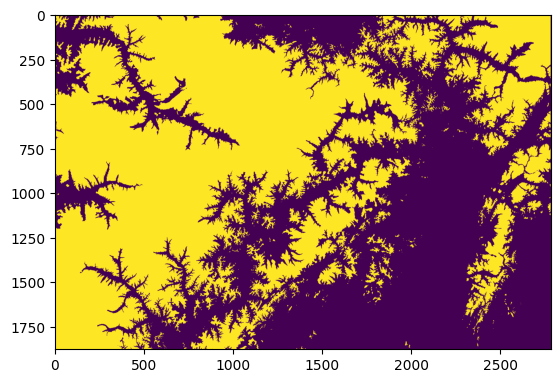

In [13]:
import matplotlib.pyplot as plt

tens = rs.open(lineaments[400]).read(1)
plt.imshow(tens > tens.mean())

In [14]:
x_sorted

NameError: name 'x_sorted' is not defined

In [ ]:
fractal_scales
x = list(fractal_scales.keys())
y = list(fractal_scales.values())

# Сортируем по x (чтобы линия не прыгала)
sorted_pairs = sorted(zip(x, y))
x_sorted, y_sorted = zip(*sorted_pairs)

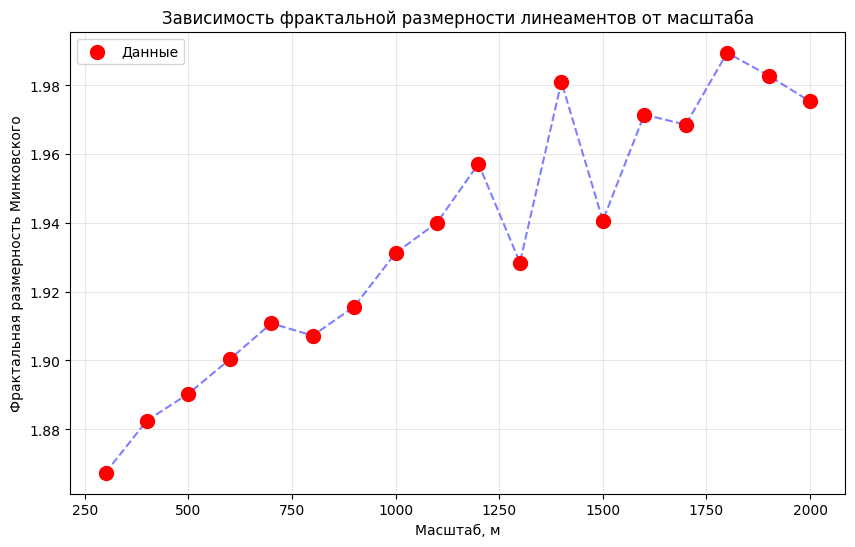

In [ ]:
# plt.plot(x_sorted ,y_sorted)

# Строим график
plt.figure(figsize=(10, 6))
plt.scatter(x_sorted, y_sorted, s=100, color='red', label='Данные', zorder=5)
plt.plot(x_sorted, y_sorted, 'b--', alpha=0.5)

plt.grid()
plt.xlabel('Масштаб, м')
plt.ylabel('Фрактальная размерность Минковского')
plt.title('Зависимость фрактальной размерности линеаментов от масштаба')
plt.grid(True, alpha=0.3)
plt.legend()

# Анализ рельефа

In [ ]:
import torch
import rasterio as rs
import torch.nn.functional as F

# Загружаем исходный DEM
with rs.open(r"D:\ml_datasets\Chukotka\DEM\dem_120m.tif") as src:
    dem = torch.tensor(src.read(1)).float()

# Добавляем размерности для батча и канала
dem_batch = dem.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]

# Создаем список тензоров с даунскейлингом от 1 до 10
downsampled_tensors = {}

for factor in range(1, 100):
    if factor == 1:
        downsampled = dem.clone()
    else:
        # Вычисляем новые размеры
        new_h = dem.shape[0] // factor
        new_w = dem.shape[1] // factor
        
        # Используем интерполяцию
        downsampled_batch = F.interpolate(
            dem_batch, 
            size=(new_h, new_w), 
            mode='bilinear', 
            align_corners=False
        )
        downsampled = downsampled_batch.squeeze()
    
    downsampled_tensors[factor] = downsampled
    print(f"Factor {factor}: {dem.shape} -> {downsampled.shape}")



Factor 1: torch.Size([6253, 9277]) -> torch.Size([6253, 9277])
Factor 2: torch.Size([6253, 9277]) -> torch.Size([3126, 4638])
Factor 3: torch.Size([6253, 9277]) -> torch.Size([2084, 3092])
Factor 4: torch.Size([6253, 9277]) -> torch.Size([1563, 2319])
Factor 5: torch.Size([6253, 9277]) -> torch.Size([1250, 1855])
Factor 6: torch.Size([6253, 9277]) -> torch.Size([1042, 1546])
Factor 7: torch.Size([6253, 9277]) -> torch.Size([893, 1325])
Factor 8: torch.Size([6253, 9277]) -> torch.Size([781, 1159])
Factor 9: torch.Size([6253, 9277]) -> torch.Size([694, 1030])
Factor 10: torch.Size([6253, 9277]) -> torch.Size([625, 927])
Factor 11: torch.Size([6253, 9277]) -> torch.Size([568, 843])
Factor 12: torch.Size([6253, 9277]) -> torch.Size([521, 773])
Factor 13: torch.Size([6253, 9277]) -> torch.Size([481, 713])
Factor 14: torch.Size([6253, 9277]) -> torch.Size([446, 662])
Factor 15: torch.Size([6253, 9277]) -> torch.Size([416, 618])
Factor 16: torch.Size([6253, 9277]) -> torch.Size([390, 579])
Fa

In [ ]:
from pathlib import Path
import torch
from utils.box_counting import get_fractal_dimension_adaptive
import rasterio as rs


fractal_scales = {}
for scale in downsampled_tensors:
    try:
        fractal_scales[scale] = get_fractal_dimension_adaptive(
            downsampled_tensors[scale] > downsampled_tensors[scale].mean())
    except:
        break

In [ ]:
get_fractal_dimention(downsampled_tensors[50])

2.017270757654889

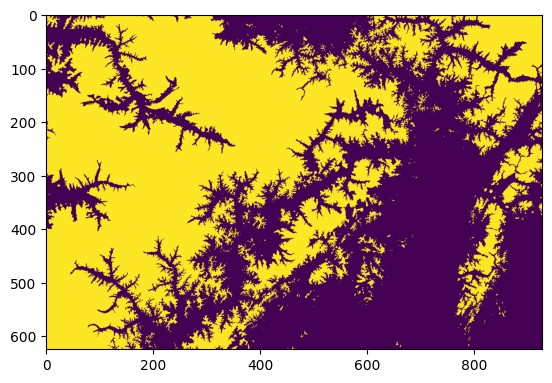

In [ ]:
plt.imshow(downsampled_tensors[10] > downsampled_tensors[66].mean())

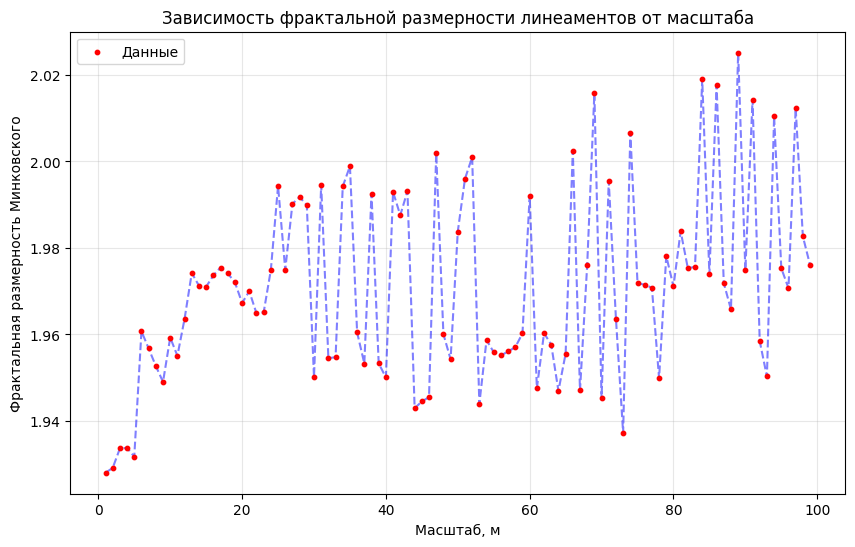

In [ ]:
import matplotlib.pyplot as plt

fractal_scales
x = list(fractal_scales.keys())
y = list(fractal_scales.values())

# Сортируем по x (чтобы линия не прыгала)
sorted_pairs = sorted(zip(x, y))
x_sorted, y_sorted = zip(*sorted_pairs)

# Строим график
plt.figure(figsize=(10, 6))
plt.scatter(x_sorted, y_sorted, s=10, color='red', label='Данные', zorder=5)
plt.plot(x_sorted, y_sorted, 'b--', alpha=0.5)

plt.grid()
plt.xlabel('Масштаб, м')
plt.ylabel('Фрактальная размерность Минковского')
plt.title('Зависимость фрактальной размерности линеаментов от масштаба')
plt.grid(True, alpha=0.3)
plt.legend()

In [ ]:
from torch import nn

m = nn.Linear(20, 30)
input = torch.randn(128, 20)
output = m(input)
print(output.size())

torch.Size([128, 30])


In [ ]:
box_size = 64



m = nn.Linear(2, 1)

binmask.shape

torch.Size([6253, 9277])

надо написать код который разбивает исходную картинку на патчи размера 64 на 64

In [7]:
patch_size = 64

H, W = binmask.shape
n_patches_h = H // patch_size
n_patches_w = W // patch_size

image_cropped = binmask[:n_patches_h*patch_size, :n_patches_h*patch_size]

patches = image_cropped.unfold(0, patch_size, patch_size).unfold(1, patch_size, patch_size)

NameError: name 'binmask' is not defined

In [6]:
image = torch.tensor([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
])  # размер [4, 4]

image.unfold(0, 2, 2).unfold(1, 2, 2)

tensor([[[[ 1,  2],
          [ 5,  6]],

         [[ 3,  4],
          [ 7,  8]]],


        [[[ 9, 10],
          [13, 14]],

         [[11, 12],
          [15, 16]]]])

In [36]:
torch.Tensor(2,2)

tensor([[0., 0.],
        [0., 0.]])

# Renorm groups

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class RenormalizationGroupLayer(nn.Module):
    """
    Слой, реализующий ренормализационную группу для изображения.
    Строит иерархию масштабов и вычисляет неподвижные точки.
    """
    def __init__(self, max_depth=5, block_sizes=None):
        super().__init__()
        self.max_depth = max_depth
        self.block_sizes = block_sizes or [2, 4, 8, 16, 32, 64]
        
        # Обучаемые параметры для разных масштабов (аналог "констант связи")
        self.coupling_constants = nn.ParameterList([
            nn.Parameter(torch.randn(1) * 0.1) for _ in range(len(self.block_sizes))
        ])
        
    def renormalize(self, x, block_size):
        """
        Один шаг ренормализации: укрупнение блоков.
        Аналог преобразования Вильсона в КТП.
        """
        B, C, H, W = x.shape
        
        # 1. Блокировка (coarse-graining)
        # Разбиваем на блоки и берем максимум (как в box-counting)
        pooled = F.max_pool2d(x, kernel_size=block_size, stride=block_size)
        
        # 2. Восстанавливаем размер (для визуализации)
        upsampled = F.interpolate(pooled, size=(H, W), mode='nearest')
        
        # 3. "Ренормализационный поток" - взвешивание с константой связи
        # Это аналог того, как меняется эффективное взаимодействие
        coupling_idx = self.block_sizes.index(block_size) if block_size in self.block_sizes else 0
        coupling = torch.sigmoid(self.coupling_constants[coupling_idx])
        
        # Комбинируем оригинал и укрупненную версию
        renormalized = (1 - coupling) * x + coupling * upsampled
        
        return renormalized, pooled
    
    def forward(self, x):
        """
        Строит всю ренормализационную групповую иерархию.
        Возвращает пирамиду изображений на разных масштабах.
        """
        pyramid = []
        pooled_pyramid = []
        
        current = x
        for i, bs in enumerate(self.block_sizes):
            if bs > min(current.shape[2:]):
                break
                
            renormalized, pooled = self.renormalize(current, bs)
            pyramid.append(renormalized)
            pooled_pyramid.append(pooled)
            
            # Для следующего шага используем пулированную версию
            current = pooled
            
        return pyramid, pooled_pyramid

In [2]:
class FixedPointDetector(nn.Module):
    """
    Обнаруживает масштабы, где изображение самоподобно
    (неподвижные точки ренормализационной группы).
    """
    def __init__(self, epsilon=0.05):
        super().__init__()
        self.epsilon = epsilon
        
    def forward(self, pyramid):
        """
        pyramid: список изображений на разных масштабах после РГ
        """
        fixed_points = []
        
        for i in range(len(pyramid)-1):
            # Сравниваем масштаб i и i+1
            img_i = pyramid[i]
            img_j = pyramid[i+1]
            
            # Приводим к одному размеру
            if img_i.shape != img_j.shape:
                img_j = F.interpolate(img_j, size=img_i.shape[2:], mode='nearest')
            
            # Вычисляем разницу
            diff = F.mse_loss(img_i, img_j)
            
            # Если разница мала — это неподвижная точка
            if diff < self.epsilon:
                fixed_points.append(i)
                
        return fixed_points

In [3]:
def visualize_rg_flow(model, image):
    """
    Визуализация ренормализационного потока для изображения.
    """
    results = model(image)
    
    fig, axes = plt.subplots(2, len(results['pyramid'])//2 + 1, figsize=(15, 6))
    
    # Оригинал
    axes[0, 0].imshow(image.squeeze().cpu(), cmap='gray')
    axes[0, 0].set_title('Оригинал')
    
    # РГ-пирамида
    for i, level in enumerate(results['pyramid']):
        row = (i+1) // (len(results['pyramid'])//2 + 1)
        col = (i+1) % (len(results['pyramid'])//2 + 1)
        axes[row, col].imshow(level.squeeze().detach().cpu(), cmap='gray')
        axes[row, col].set_title(f'Масштаб {i+1}')
    
    # Неподвижные точки
    for scale in results['fixed_scales']:
        axes[0, 0].axvline(x=scale, color='r', linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Глобальная размерность: {results['global_dim'].item():.3f}")
    print(f"Неподвижные точки на масштабах: {results['fixed_scales']}")
    print(f"РГ-поток: {results['rg_flow'].detach().cpu().numpy()}")